#COMPSCI 546: Applied Information Retrieval - Spring 2026 ([website](https://groups.cs.umass.edu/zamani/compsci-546-applied-information-retrieval-spring-2026/))
##Assignment 8: Collaborative Recommender Systems (Total : 100 points)

**Description**

This assignment consists of programming and analytical questions on Collaborative Filtering (also known as Collaborative Recommender Systems).

**Instructions**

* To start working on the assignment, you would first need to save the notebook to your local Google Drive. For this purpose, you can click on *Copy to Drive* button. You can alternatively click the *Share* button located at the top right corner and click on *Copy Link* under *Get Link* to get a link and copy this notebook to your Google Drive.  

*   For questions with descriptive answers, please replace the text in the cell which states "Enter your answer here!" with your answer. If you are using mathematical notation in your answers, please define the variables.
*   You should implement all the functions yourself and should not use a library or tool for the computation. You can use TensorFlow functions, if needed.
*   For coding questions, you can add code where it says "enter code here" and execute the cell to print the output.
* To create the final pdf submission file, execute *Runtime->RunAll* from the menu to re-execute all the cells and then generate a PDF using *File->Print->Save as PDF*. Make sure that the generated PDF contains all the codes and printed outputs before submission.
* Credit: This assignment is a modified version of the Colab created and distributed by Google as part of Recommender Systems with TensorFlow.


**Submission Details**

* Due date: May 8, 2026 at 11:59 PM (EDT).
* The final PDF file must be uploaded on Gradescope.
* After copying this notebook to your Google Drive, please paste a link to it below. Use the same process given above to generate a link. ***You will not recieve any credit if you don't paste the link!*** Make sure we can access the file.
***LINK: https://colab.research.google.com/drive/1-is2GsI239oDUfHaTwsfgITWU8OWnC2g?usp=sharing***

**Academic Honesty**

Please follow the guidelines under the *Collaboration and Help* section of the course website.     

# Download input files


In this assignment, you will work with the MovieLens 100K dataset, which consists of 100,000  ratings corresponding to 943 users and 1682 movies/items.  Execute the two cells given below to perform the initial set-up and download the data. You can ignore the error about downloading from github.

In [5]:

from __future__ import print_function

import numpy as np
import pandas as pd
import collections
from mpl_toolkits.mplot3d import Axes3D
from IPython import display
from matplotlib import pyplot as plt
import sklearn
import sklearn.manifold
import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()
tf.logging.set_verbosity(tf.logging.ERROR)

# Add some convenience functions to Pandas DataFrame.
pd.options.display.max_rows = 10
pd.options.display.float_format = '{:.3f}'.format
def mask(df, key, function):
  """Returns a filtered dataframe, by applying function to key"""
  return df[function(df[key])]

def flatten_cols(df):
  df.columns = [' '.join(col).strip() for col in df.columns.values]
  return df

pd.DataFrame.mask = mask
pd.DataFrame.flatten_cols = flatten_cols

# Install Altair and activate its colab renderer.
print("Installing Altair...")
#!pip install git+git://github.com/altair-viz/altair.git
!pip install altair
import altair as alt
alt.data_transformers.enable('default', max_rows=None)
alt.renderers.enable('colab')
print("Done installing Altair.")

# Install spreadsheets and import authentication module.
USER_RATINGS = True
!pip install --upgrade -q gspread
from google.colab import auth
import gspread
from oauth2client.client import GoogleCredentials

Installing Altair...
Done installing Altair.


In [6]:

# Download MovieLens data.
print("Downloading movielens data...")
from urllib.request import urlretrieve
import zipfile

urlretrieve("http://files.grouplens.org/datasets/movielens/ml-100k.zip", "movielens.zip")
zip_ref = zipfile.ZipFile('movielens.zip', "r")
zip_ref.extractall()
print("Done. Dataset contains:")
print(zip_ref.read('ml-100k/u.info'))

# Load each data set (users, movies, and ratings).
users_cols = ['user_id', 'age', 'sex', 'occupation', 'zip_code']
users = pd.read_csv(
    'ml-100k/u.user', sep='|', names=users_cols, encoding='latin-1')

ratings_cols = ['user_id', 'movie_id', 'rating', 'unix_timestamp']
ratings = pd.read_csv(
    'ml-100k/u.data', sep='\t', names=ratings_cols, encoding='latin-1')

# The movies file contains a binary feature for each genre.
genre_cols = [
    "genre_unknown", "Action", "Adventure", "Animation", "Children", "Comedy",
    "Crime", "Documentary", "Drama", "Fantasy", "Film-Noir", "Horror",
    "Musical", "Mystery", "Romance", "Sci-Fi", "Thriller", "War", "Western"
]
movies_cols = [
    'movie_id', 'title', 'release_date', "video_release_date", "imdb_url"
] + genre_cols
movies = pd.read_csv(
    'ml-100k/u.item', sep='|', names=movies_cols, encoding='latin-1')

# Since the ids start at 1, we shift them to start at 0.
users["user_id"] = users["user_id"].apply(lambda x: str(x-1))
movies["movie_id"] = movies["movie_id"].apply(lambda x: str(x-1))
movies["year"] = movies['release_date'].apply(lambda x: str(x).split('-')[-1])
ratings["movie_id"] = ratings["movie_id"].apply(lambda x: str(x-1))
ratings["user_id"] = ratings["user_id"].apply(lambda x: str(x-1))
ratings["rating"] = ratings["rating"].apply(lambda x: float(x))

# Compute the number of movies to which a genre is assigned.
genre_occurences = movies[genre_cols].sum().to_dict()

# Since some movies can belong to more than one genre, we create different
# 'genre' columns as follows:
# - all_genres: all the active genres of the movie.
# - genre: randomly sampled from the active genres.
def mark_genres(movies, genres):
  def get_random_genre(gs):
    active = [genre for genre, g in zip(genres, gs) if g==1]
    if len(active) == 0:
      return 'Other'
    return np.random.choice(active)
  def get_all_genres(gs):
    active = [genre for genre, g in zip(genres, gs) if g==1]
    if len(active) == 0:
      return 'Other'
    return '-'.join(active)
  movies['genre'] = [
      get_random_genre(gs) for gs in zip(*[movies[genre] for genre in genres])]
  movies['all_genres'] = [
      get_all_genres(gs) for gs in zip(*[movies[genre] for genre in genres])]

mark_genres(movies, genre_cols)

# Create one merged DataFrame containing all the movielens data.
movielens = ratings.merge(movies, on='movie_id').merge(users, on='user_id')

# Utility to split the data into training and test sets.
def split_dataframe(df, holdout_fraction=0.1):
  """Splits a DataFrame into training and test sets.
  Args:
    df: a dataframe.
    holdout_fraction: fraction of dataframe rows to use in the test set.
  Returns:
    train: dataframe for training
    test: dataframe for testing
  """
  test = df.sample(frac=holdout_fraction, replace=False)
  train = df[~df.index.isin(test.index)]
  return train, test

Done. Dataset contains:
b'943 users\n1682 items\n100000 ratings\n'


# 1. Initial Data Preparation (20 points)

Our goal is to factorize the ratings matrix $A$ into the product of a user embedding matrix $U$ and movie embedding matrix $V$, such that $A \approx UV^\top$ with
$U = \begin{bmatrix} u_{1} \\ \hline \vdots \\ \hline u_{N} \end{bmatrix}$ and
$V = \begin{bmatrix} v_{1} \\ \hline \vdots \\ \hline v_{M} \end{bmatrix}$.

Here
- $N$ is the number of users,
- $M$ is the number of movies,
- $A_{ij}$ is the rating of the $j$th movies by the $i$th user,
- each row $U_i$ is a $d$-dimensional vector (embedding) representing user $i$,
- each row $V_j$ is a $d$-dimensional vector (embedding) representing movie $j$,
- the prediction of the model for the $(i, j)$ pair is the dot product $\langle U_i, V_j \rangle$.



**Sparse Representation of the Rating Matrix**

The rating matrix could be very large and, in general, most of the entries are unobserved, since a given user will only rate a small subset of movies. For effcient representation, we will use a [tf.SparseTensor](https://www.tensorflow.org/api_docs/python/tf/SparseTensor). A `SparseTensor` uses three tensors to represent the matrix: `tf.SparseTensor(indices, values, dense_shape)` represents a tensor, where a value $A_{ij} = a$ is encoded by setting `indices[k] = [i, j]` and `values[k] = a`. The last tensor `dense_shape` is used to specify the shape of the full underlying matrix.

**Toy example**

Assume we have $2$ users and $4$ movies. Our toy ratings dataframe has three ratings,

user\_id | movie\_id | rating
--:|--:|--:
0 | 0 | 5.0
0 | 1 | 3.0
1 | 3 | 1.0

The corresponding rating matrix is

$$
A =
\begin{bmatrix}
5.0 & 3.0 & 0 & 0 \\
0   &   0 & 0 & 1.0
\end{bmatrix}
$$

And the SparseTensor representation is,
```python
SparseTensor(
  indices=[[0, 0], [0, 1], [1,3]],
  values=[5.0, 3.0, 1.0],
  dense_shape=[2, 4])
```



In the cell below, build a tf.SparseTensor representation of the Rating Matrix.

Here, we'll write a function that maps from our `ratings` DataFrame to a `tf.SparseTensor`.

Hint: you can select the values of a given column of a Dataframe `df` using `df['column_name'].values`.

In [7]:
def build_rating_sparse_tensor(ratings_df):
  """
  Args:
    ratings_df: a pd.DataFrame with `user_id`, `movie_id` and `rating` columns.
  Returns:
    A tf.SparseTensor representing the ratings matrix.
  """

  #============================================================================
  #enter your code here
  indices = []
  values = []

  user_ids = ratings_df['user_id'].astype(int).values
  movie_ids = ratings_df['movie_id'].astype(int).values
  ratings = ratings_df['rating'].values

  for i in range(len(user_ids)):
    indices.append([user_ids[i], movie_ids[i]])
    values.append(ratings[i])
  #============================================================================

  return tf.SparseTensor(
      indices=indices,
      values=values,
      dense_shape=[users.shape[0], movies.shape[0]])

**Calculating the error**

The model approximates the ratings matrix $A$ by a low-rank product $UV^\top$. We need a way to measure the approximation error. We'll start by using the Mean Squared Error of observed entries only. It is defined as

$$
\begin{align*}
\text{MSE}(A, UV^\top)
&= \frac{1}{|\Omega|}\sum_{(i, j) \in\Omega}{( A_{ij} - (UV^\top)_{ij})^2} \\
&= \frac{1}{|\Omega|}\sum_{(i, j) \in\Omega}{( A_{ij} - \langle U_i, V_j\rangle)^2}
\end{align*}
$$
where $\Omega$ is the set of observed ratings, and $|\Omega|$ is the cardinality of $\Omega$.



**Mean Squared Error**

Write a TensorFlow function that takes a sparse rating matrix $A$ and the two embedding matrices $U, V$ and returns the mean squared error $\text{MSE}(A, UV^\top)$.

Hints:
  * in this section, we only consider observed entries when calculating the loss.
  * a `SparseTensor` `sp_x` is a tuple of three Tensors: `sp_x.indices`, `sp_x.values` and `sp_x.dense_shape`.
  * you may find [`tf.gather_nd`](https://www.tensorflow.org/api_docs/python/tf/gather_nd) and  [`tf.losses.mean_squared_error`](https://www.tensorflow.org/api_docs/python/tf/losses/mean_squared_error) helpful.

In [16]:
def sparse_mean_square_error(sparse_ratings, user_embeddings, movie_embeddings):
  """
  Args:
    sparse_ratings: A SparseTensor rating matrix, of dense_shape [N, M]
    user_embeddings: A dense Tensor U of shape [N, k] where k is the embedding
      dimension, such that U_i is the embedding of user i.
    movie_embeddings: A dense Tensor V of shape [M, k] where k is the embedding
      dimension, such that V_j is the embedding of movie j.
  Returns:
    A scalar Tensor representing the MSE between the true ratings and the
      model's predictions.
  """

  #============================================================================
  #enter your code here
  # Get user/movie indices for observed ratings only
  user_indices = sparse_ratings.indices[:, 0]
  movie_indices = sparse_ratings.indices[:, 1]

  # Gather the corresponding embeddings
  user_vectors = tf.gather(user_embeddings, user_indices)
  movie_vectors = tf.gather(movie_embeddings, movie_indices)

  # Dot product for each observed (user, movie) pair
  predictions = tf.reduce_sum(user_vectors * movie_vectors, axis=1)

  # Compare predicted ratings with true observed ratings
  loss = tf.losses.mean_squared_error(sparse_ratings.values, predictions)
  #============================================================================
  return loss

# 2. Adding your own ratings to the data set (10 points)

You have to add your own ratings to the data set. The ratings are values between between 1 and 5 (inclusive). You will be able to see recommendations for yourself.

Start by checking the box below. Running the next cell will authenticate you to your google Drive account, and create a spreadsheet, that contains all movie titles in column 'A'. Follow the link to the spreadsheet and take 3 minutes to rate some of the movies. Your ratings should be entered in column 'B'.

In [9]:
# Authenticate user.
import gspread
from google.auth import default
if USER_RATINGS:
  auth.authenticate_user()
  #gc = gspread.authorize(GoogleCredentials.get_application_default())
  creds, _ = default()
  gc = gspread.authorize(creds)
  # Create the spreadsheet and print a link to it.

  try:
    sh = gc.open('MovieLens-test')
  except(gspread.SpreadsheetNotFound):
    sh = gc.create('MovieLens-test')

  worksheet = sh.sheet1
  titles = movies['title'].values
  cell_list = worksheet.range(1, 1, len(titles), 1)
  for cell, title in zip(cell_list, titles):
    cell.value = title
  worksheet.update_cells(cell_list)
  print("Link to the spreadsheet: "
        "https://docs.google.com/spreadsheets/d/{}/edit".format(sh.id))

Link to the spreadsheet: https://docs.google.com/spreadsheets/d/1FodpPHi2bUBA__ZK2vdmDP5kQ3pLE34VVuI0d_bjOqs/edit


Run the next  cell to load your ratings and add them to the main `ratings` DataFrame.

In [12]:

# Load the ratings from the spreadsheet and create a DataFrame.
if USER_RATINGS:
  my_ratings = pd.DataFrame.from_records(worksheet.get_all_values()).reset_index()
  my_ratings = my_ratings[my_ratings[1] != '']
  my_ratings = pd.DataFrame({
      'user_id': "943",
      'movie_id': list(map(str, my_ratings['index'])),
      'rating': list(map(float, my_ratings[1])),
  })
  # Remove previous ratings.
  ratings = ratings[ratings.user_id != "943"]
  # Add new ratings.
  # ratings = ratings.append(my_ratings, ignore_index=True)
  ratings = pd.concat([ratings, my_ratings], ignore_index=True)
  # Add new user to the users DataFrame.
  if users.shape[0] == 943:
    # users = users.append(users.iloc[942], ignore_index=True)
    users = pd.concat([users, users.iloc[[942]]], ignore_index=True)
    users["user_id"][943] = "943"
  print("Added your %d ratings; you have great taste!" % len(my_ratings))
  ratings[ratings.user_id=="943"].merge(movies[['movie_id', 'title']])

Added your 33 ratings; you have great taste!


/tmp/ipykernel_2367/482135573.py:19: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  users["user_id"][943] = "943"
/tmp/ipykernel_2367/482135573.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame


# 3. Training a Matrix Factorization model (20 points)

## CFModel (Collaborative Filtering Model) helper class
This is a simple class to train a matrix factorization model using stochastic gradient descent.

The class constructor takes
- the user embeddings U (a `tf.Variable`).
- the movie embeddings V, (a `tf.Variable`).
- a loss to optimize (a `tf.Tensor`).
- an optional list of metrics dictionaries, each mapping a string (the name of the metric) to a tensor. These are evaluated and plotted during training (e.g. training error and test error).

After training, one can access the trained embeddings using the `model.embeddings` dictionary.

Example usage:
```
U_var = ...
V_var = ...
loss = ...
model = CFModel(U_var, V_var, loss)
model.train(iterations=100, learning_rate=1.0)
user_embeddings = model.embeddings['user_id']
movie_embeddings = model.embeddings['movie_id']
```


In [13]:
class CFModel(object):
  """Simple class that represents a collaborative filtering model"""
  def __init__(self, embedding_vars, loss, metrics=None):
    """Initializes a CFModel.
    Args:
      embedding_vars: A dictionary of tf.Variables.
      loss: A float Tensor. The loss to optimize.
      metrics: optional list of dictionaries of Tensors. The metrics in each
        dictionary will be plotted in a separate figure during training.
    """
    self._embedding_vars = embedding_vars
    self._loss = loss
    self._metrics = metrics
    self._embeddings = {k: None for k in embedding_vars}
    self._session = None

  @property
  def embeddings(self):
    """The embeddings dictionary."""
    return self._embeddings

  def train(self, num_iterations=100, learning_rate=1.0, plot_results=True,
            optimizer=tf.train.GradientDescentOptimizer):
    """Trains the model.
    Args:
      iterations: number of iterations to run.
      learning_rate: optimizer learning rate.
      plot_results: whether to plot the results at the end of training.
      optimizer: the optimizer to use. Default to GradientDescentOptimizer.
    Returns:
      The metrics dictionary evaluated at the last iteration.
    """
    with self._loss.graph.as_default():
      opt = optimizer(learning_rate)
      train_op = opt.minimize(self._loss)
      local_init_op = tf.group(
          tf.variables_initializer(opt.variables()),
          tf.local_variables_initializer())
      if self._session is None:
        self._session = tf.Session()
        with self._session.as_default():
          self._session.run(tf.global_variables_initializer())
          self._session.run(tf.tables_initializer())
          tf.train.start_queue_runners()

    with self._session.as_default():
      local_init_op.run()
      iterations = []
      metrics = self._metrics or ({},)
      metrics_vals = [collections.defaultdict(list) for _ in self._metrics]

      # Train and append results.
      for i in range(num_iterations + 1):
        _, results = self._session.run((train_op, metrics))
        if (i % 10 == 0) or i == num_iterations:
          print("\r iteration %d: " % i + ", ".join(
                ["%s=%f" % (k, v) for r in results for k, v in r.items()]),
                end='')
          iterations.append(i)
          for metric_val, result in zip(metrics_vals, results):
            for k, v in result.items():
              metric_val[k].append(v)

      for k, v in self._embedding_vars.items():
        self._embeddings[k] = v.eval()

      if plot_results:
        # Plot the metrics.
        num_subplots = len(metrics)+1
        fig = plt.figure()
        fig.set_size_inches(num_subplots*10, 8)
        for i, metric_vals in enumerate(metrics_vals):
          ax = fig.add_subplot(1, num_subplots, i+1)
          for k, v in metric_vals.items():
            ax.plot(iterations, v, label=k)
          ax.set_xlim([1, num_iterations])
          ax.legend()
      return results

**Build a Matrix Factorization model and train it**

Using your `sparse_mean_square_error` function, write a function that builds a `CFModel` by creating the embedding variables and the train and test losses.

In [14]:
def build_model(ratings, embedding_dim=3, init_stddev=1.):
  """
  Args:
    ratings: a DataFrame of the ratings
    embedding_dim: the dimension of the embedding vectors.
    init_stddev: float, the standard deviation of the random initial embeddings.
  Returns:
    model: a CFModel.
  """
  # Split the ratings DataFrame into train and test.
  train_ratings, test_ratings = split_dataframe(ratings)

  # SparseTensor representation of the train and test datasets.
  #============================================================================
  #enter your code here
  A_train = build_rating_sparse_tensor(train_ratings)
  A_test = build_rating_sparse_tensor(test_ratings)
  #============================================================================

  # Initialize the embeddings using a normal distribution.
  U = tf.Variable(tf.random_normal(
      [A_train.dense_shape[0], embedding_dim], stddev=init_stddev))
  V = tf.Variable(tf.random_normal(
      [A_train.dense_shape[1], embedding_dim], stddev=init_stddev))

  #============================================================================
  #enter your code here
  train_loss = sparse_mean_square_error(A_train, U, V)
  test_loss = sparse_mean_square_error(A_test, U, V)
  #============================================================================


  metrics = {
      'train_error': train_loss,
      'test_error': test_loss
  }
  embeddings = {
      "user_id": U,
      "movie_id": V
  }
  return CFModel(embeddings, train_loss, [metrics])

Great, now it's time to train the model!

Go ahead and run the next cell, trying different parameters (embedding dimension, learning rate, iterations). The training and test errors are plotted at the end of training. You can inspect these values to validate the hyper-parameters.

Note: by calling `model.train` again, the model will continue training starting from the current values of the embeddings.

 iteration 1000: train_error=0.372209, test_error=1.322887

[{'train_error': np.float32(0.37220886), 'test_error': np.float32(1.3228866)}]

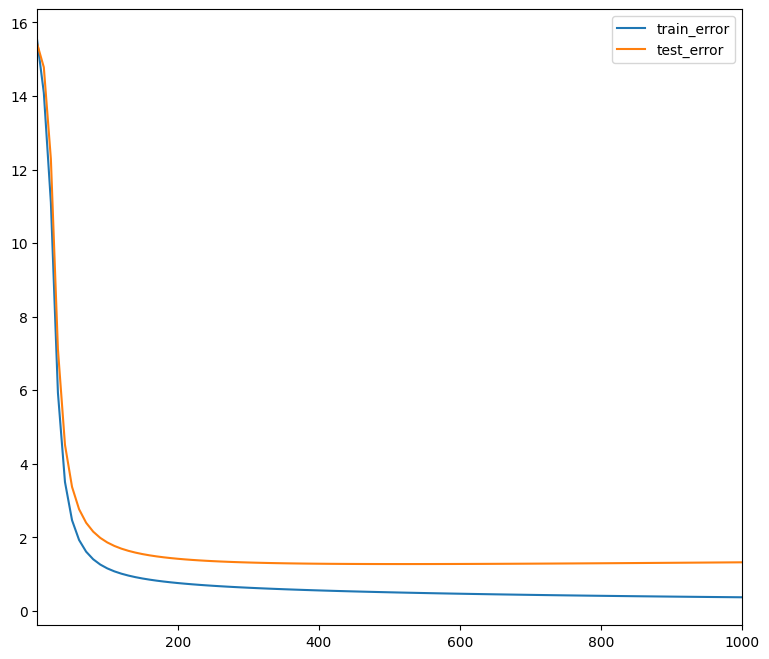

In [17]:
# Build the CF model and train it.
model = build_model(ratings, embedding_dim=30, init_stddev=0.5)
model.train(num_iterations=1000, learning_rate=10.)

# 4. Inspecting the Embeddings (30 points)

In this section, we take a closer look at the learned embeddings, by
- computing your recommendations
- looking at the nearest neighbors of some movies,


**Write a function that computes the scores of the candidates**

We start by writing a function that, given a query embedding $u \in \mathbb R^d$ and item embeddings $V \in \mathbb R^{N \times d}$, computes the item scores.

As discussed in the lecture, there are different similarity measures we can use, and these can yield different results. We will compare the following:
- dot product: the score of item j is $\langle u, V_j \rangle$.
- cosine: the score of item j is $\frac{\langle u, V_j \rangle}{\|u\|\|V_j\|}$.

Hints:
- you can use [`np.dot`](https://docs.scipy.org/doc/numpy/reference/generated/numpy.dot.html) to compute the product of two np.Arrays.
- you can use [`np.linalg.norm`](https://docs.scipy.org/doc/numpy-1.14.0/reference/generated/numpy.linalg.norm.html) to compute the norm of a np.Array.

In [18]:
DOT = 'dot'
COSINE = 'cosine'
def compute_scores(query_embedding, item_embeddings, measure=DOT):
  """Computes the scores of the candidates given a query.
  Args:
    query_embedding: a vector of shape [k], representing the query embedding.
    item_embeddings: a matrix of shape [N, k], such that row i is the embedding
      of item i.
    measure: a string specifying the similarity measure to be used. Can be
      either DOT or COSINE.
  Returns:
    scores: a vector of shape [N], such that scores[i] is the score of item i.
  """
  #============================================================================
  #enter your code here
  if measure == DOT:
    scores = np.dot(item_embeddings, query_embedding)

  elif measure == COSINE:
    dot_scores = np.dot(item_embeddings, query_embedding)
    query_norm = np.linalg.norm(query_embedding)
    item_norms = np.linalg.norm(item_embeddings, axis=1)
    scores = dot_scores / (query_norm * item_norms)

  else:
    raise ValueError("Unknown similarity measure: %s" % measure)
  #============================================================================

  return scores

Equipped with this function, we can compute recommendations, where the query embedding can be either a user embedding or a movie embedding.

In [19]:

def user_recommendations(model, measure=DOT, exclude_rated=False, k=6):
  if USER_RATINGS:
    scores = compute_scores(
        model.embeddings["user_id"][943], model.embeddings["movie_id"], measure)
    score_key = measure + ' score'
    df = pd.DataFrame({
        score_key: list(scores),
        'movie_id': movies['movie_id'],
        'titles': movies['title'],
        'genres': movies['all_genres'],
    })
    if exclude_rated:
      # remove movies that are already rated
      rated_movies = ratings[ratings.user_id == "943"]["movie_id"].values
      df = df[df.movie_id.apply(lambda movie_id: movie_id not in rated_movies)]
    display.display(df.sort_values([score_key], ascending=False).head(k))

def movie_neighbors(model, title_substring, measure=DOT, k=6):
  # Search for movie ids that match the given substring.
  ids =  movies[movies['title'].str.contains(title_substring)].index.values
  titles = movies.iloc[ids]['title'].values
  if len(titles) == 0:
    raise ValueError("Found no movies with title %s" % title_substring)
  print("Nearest neighbors of : %s." % titles[0])
  if len(titles) > 1:
    print("[Found more than one matching movie. Other candidates: {}]".format(
        ", ".join(titles[1:])))
  movie_id = ids[0]
  scores = compute_scores(
      model.embeddings["movie_id"][movie_id], model.embeddings["movie_id"],
      measure)
  score_key = measure + ' score'
  df = pd.DataFrame({
      score_key: list(scores),
      'titles': movies['title'],
      'genres': movies['all_genres']
  })
  display.display(df.sort_values([score_key], ascending=False).head(k))

**User recommendations**

You can run the next cell to generate recommendations for you.

In [20]:
user_recommendations(model, measure=DOT, k=5)
user_recommendations(model, measure=COSINE, k=5)

,dot score,movie_id,titles,genres
489,6.913,489,To Catch a Thief (1955),Comedy-Romance-Thriller
237,6.775,237,Raising Arizona (1987),Comedy
748,6.346,748,"MatchMaker, The (1997)",Comedy-Romance
52,6.333,52,Natural Born Killers (1994),Action-Thriller
156,6.215,156,Platoon (1986),Drama-War


,cosine score,movie_id,titles,genres
237,0.731,237,Raising Arizona (1987),Comedy
217,0.724,217,Cape Fear (1991),Thriller
269,0.701,269,Gattaca (1997),Drama-Sci-Fi-Thriller
1304,0.698,1304,National Lampoon's Senior Trip (1995),Comedy
353,0.683,353,"Wedding Singer, The (1998)",Comedy-Romance


**Movie Recommendations**

Let's look at the nearest neighbors for some of the movies.

In [21]:
movie_neighbors(model, "Braveheart", DOT, k=5)
movie_neighbors(model, "Braveheart", COSINE, k =5)

Nearest neighbors of : Braveheart (1995).


,dot score,titles,genres
21,7.364,Braveheart (1995),Action-Drama-War
643,6.246,"Thin Blue Line, The (1988)",Documentary
312,6.134,Titanic (1997),Action-Drama-Romance
81,6.080,Jurassic Park (1993),Action-Adventure-Sci-Fi
63,6.078,"Shawshank Redemption, The (1994)",Drama


Nearest neighbors of : Braveheart (1995).


,cosine score,titles,genres
21,1.000,Braveheart (1995),Action-Drama-War
81,0.864,Jurassic Park (1993),Action-Adventure-Sci-Fi
78,0.840,"Fugitive, The (1993)",Action-Thriller
63,0.839,"Shawshank Redemption, The (1994)",Drama
97,0.837,"Silence of the Lambs, The (1991)",Drama-Thriller


**Movie Embedding Norm**

We can also observe that the recommendations with dot-product and cosine are different: with dot-product, the model tends to recommend popular movies. This can be explained by the fact that in matrix factorization models, the norm of the embedding is often correlated with popularity (popular movies have a larger norm), which makes it more likely to recommend more popular items. We can confirm this hypothesis by sorting the movies by their embedding norm, as done in the next cells.

In [22]:
movies_ratings = movies.merge(
    ratings
    .groupby('movie_id', as_index=False)
    .agg({'rating': ['count', 'mean']})
    .flatten_cols(),
    on='movie_id')

genre_filter = alt.selection_multi(fields=['genre'])
genre_chart = alt.Chart().mark_bar().encode(
    x="count()",
    y=alt.Y('genre'),
    color=alt.condition(
        genre_filter,
        alt.Color("genre:N"),
        alt.value('lightgray'))
).properties(height=300, selection=genre_filter)

/tmp/ipykernel_2367/1014450904.py:8: AltairDeprecationWarning: 
Deprecated since `altair=5.0.0`. Use selection_point instead.
  genre_filter = alt.selection_multi(fields=['genre'])


In [25]:

def movie_embedding_norm(models):
  """Visualizes the norm and number of ratings of the movie embeddings.
  Args:
    model: A MFModel object.
  """
  if not isinstance(models, list):
    models = [models]
  df = pd.DataFrame({
      'title': movies['title'],
      'genre': movies['genre'],
      'num_ratings': movies_ratings['rating count'],
  })
  charts = []
  brush = alt.selection_interval()
  for i, model in enumerate(models):
    norm_key = 'norm'+str(i)
    df[norm_key] = np.linalg.norm(model.embeddings["movie_id"], axis=1)
    # nearest = alt.selection(
    #     type='single', encodings=['x', 'y'], on='mouseover', nearest=True,
    #     empty='none')
    # base = alt.Chart().mark_circle().encode(
    #     x='num_ratings',
    #     y=norm_key,
    #     color=alt.condition(brush, alt.value('#4c78a8'), alt.value('lightgray'))
    # ).properties(
    #     selection=nearest).add_selection(brush)
    nearest = alt.selection_point(
    encodings=['x', 'y'], on='mouseover', nearest=True, empty=False)

    base = alt.Chart().mark_circle().encode(
        x='num_ratings',
        y=norm_key,
        color=alt.condition(brush, alt.value('#4c78a8'), alt.value('lightgray'))
    ).add_params(
        nearest, brush
    )
    text = alt.Chart().mark_text(align='center', dx=5, dy=-5).encode(
        x='num_ratings', y=norm_key,
        text=alt.condition(nearest, 'title', alt.value('')))
    charts.append(alt.layer(base, text))
  return alt.hconcat(*charts, data=df)

def visualize_movie_embeddings(data, x, y):
  nearest = alt.selection(
      type='single', encodings=['x', 'y'], on='mouseover', nearest=True,
      empty='none')
  base = alt.Chart().mark_circle().encode(
      x=x,
      y=y,
      color=alt.condition(genre_filter, "genre", alt.value("whitesmoke")),
  ).properties(
      width=600,
      height=600,
      selection=nearest)
  text = alt.Chart().mark_text(align='left', dx=5, dy=-5).encode(
      x=x,
      y=y,
      text=alt.condition(nearest, 'title', alt.value('')))
  return alt.hconcat(alt.layer(base, text), genre_chart, data=data)

def tsne_movie_embeddings(model):
  """Visualizes the movie embeddings, projected using t-SNE with Cosine measure.
  Args:
    model: A MFModel object.
  """
  tsne = sklearn.manifold.TSNE(
      n_components=2, perplexity=40, metric='cosine', early_exaggeration=10.0,
      init='pca', verbose=True, n_iter=400)

  print('Running t-SNE...')
  V_proj = tsne.fit_transform(model.embeddings["movie_id"])
  movies.loc[:,'x'] = V_proj[:, 0]
  movies.loc[:,'y'] = V_proj[:, 1]
  return visualize_movie_embeddings(movies, 'x', 'y')

In [26]:
movie_embedding_norm(model)

alt.HConcatChart(...)

Note: Depending on how the model is initialized, you may observe that some niche movies (ones with few ratings) have a high norm, leading to spurious recommendations. This can happen if the embedding of that movie happens to be initialized with a high norm. Then, because the movie has few ratings, it is infrequently updated, and can keep its high norm. This will be alleviated by using regularization.

Try changing the value of the hyper-parameter `init_stddev`. One quantity that can be helpful is that the expected norm of a $d$-dimensional vector with entries $\sim \mathcal N(0, \sigma^2)$ is approximatley $\sigma \sqrt d$.

Observe how this affects the embedding norm distribution, and the ranking of the top-norm movies?


 iteration 1000: train_error=0.333868, test_error=1.029484Nearest neighbors of : Priest (1994).


,dot score,titles,genres
56,10.575,Priest (1994),Drama
920,6.857,Farewell My Concubine (1993),Drama-Romance
1166,6.554,"Sum of Us, The (1994)",Comedy
696,6.494,"Basketball Diaries, The (1995)",Drama
39,6.468,"To Wong Foo, Thanks for Everything! Julie Newm...",Comedy
1202,6.452,Top Hat (1935),Comedy-Musical-Romance


Nearest neighbors of : Priest (1994).


,dot score,titles,genres
56,6.278,Priest (1994),Drama
514,5.281,"Boot, Das (1981)",Action-Drama-War
169,5.001,Cinema Paradiso (1988),Comedy-Drama-Romance
356,4.985,One Flew Over the Cuckoo's Nest (1975),Drama
381,4.929,"Adventures of Priscilla, Queen of the Desert, ...",Comedy-Drama
131,4.913,"Wizard of Oz, The (1939)",Adventure-Children-Drama-Musical


alt.HConcatChart(...)

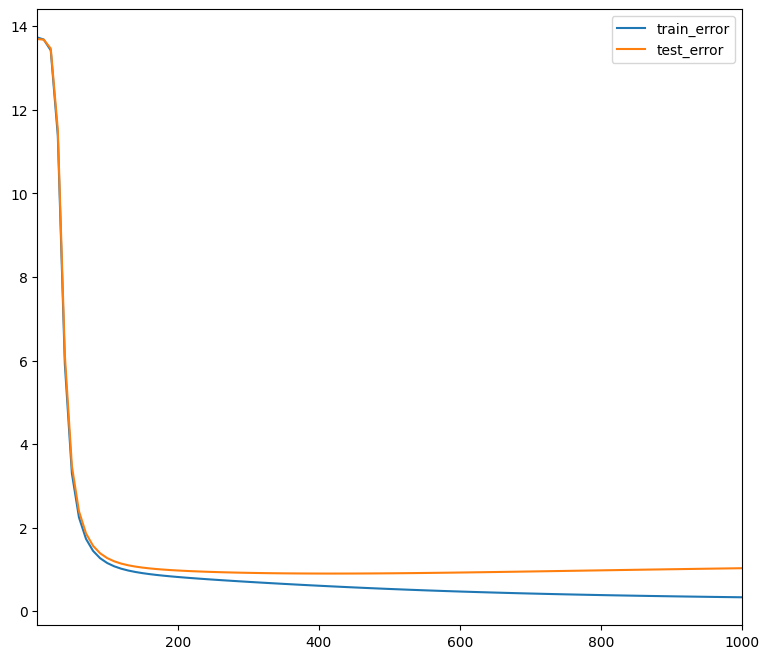

In [27]:

#============================================================================
#enter your code here
init_stddev = 0.1
# use build_model function
model_lowinit = build_model(ratings, embedding_dim=30, init_stddev=init_stddev)
#============================================================================
model_lowinit.train(num_iterations=1000, learning_rate=10.)
movie_neighbors(model, "Priest", DOT)
movie_neighbors(model_lowinit, "Priest", DOT)
movie_embedding_norm([model, model_lowinit])


# 5. Analytical Questions (20 points)


**Question 5.1** Describe one of the shortcomings of Collaborative Filtering models? How can one solve this issue? (10 points)

***Answer:***\
One of the shortcoming of collaborative filtering is that it can suffer from col-start and sparsity problems. We noticed that the model learns about user and item embeddings only through observed interactions, such as ratings. If a new user has rated very few movies, or a new movie has very few ratings, then the model does not have enough information to learn a meaningful embedding. In our experiment, we also saw that movies with few ratings can sometimes have unstable or unusually large embedding norms because they are updated infrequently during training. This can lead to noisy or spurious recommendations.\
\
One way to solve this issue is to use regularization. Regularization penalizes very large embedding values, which helps prevent rarely rated movies from keeping accidentally large norms.\
\
One other solution is to use model where we have side information such as movie genres, descriptions, actors, user demographics, or content features. This helps the system make better recommendations even when there are few collaborative ratings available.

**Question 5.2** Properties and purposes of recommendation algorithms differ across domains. For example, in movie recommendation, the system often does not recommend the movies that the user has watched in the past, while in music recommendation, it is likely that a user listens to a music over and over. How would you modify the typical collaborative filtering models for the music domain? (10 points)

***Answer:***\
For music recommendation, the meaning of user behavior is different from movie recommendation. In movie recommendation, if a user already watched a movie, we usually do not need to recommend the same movie again. But in music recommendation, repeated listening is normal and important. If a user listens to the same song many times, that is a strong positive signal rather than a reason to remove it from recommendations.\
To adapt collaborative filtering for music, I would change the interaction data from explicit ratings to implicit feedback, such as play counts, repeat listens, skips, likes, saves, and playlist additions. The model should allow previously listened songs to appear again, but rank them based on context and repeated engagement. For instance, a song played many times could receive a higher confidence weight, while skipped songs could receive a lower or negative signal, I would also include time/context features, since music tast can depend on mood, time of day, activity, or recent listening history. So instead of simply predicting a rating, the model should predict the likelihood that the user will listen to or replay a song in a given context.